<a href="https://colab.research.google.com/github/io-uty/skt-bigdata-analysis/blob/main/22_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3. 이진분류

In [2]:
import pandas as pd

diabetes = pd.read_csv('./diabetes.csv')
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
diabetes.isna().sum(axis=0)

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [5]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI']
(diabetes[cols]==0).sum(axis=0)

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


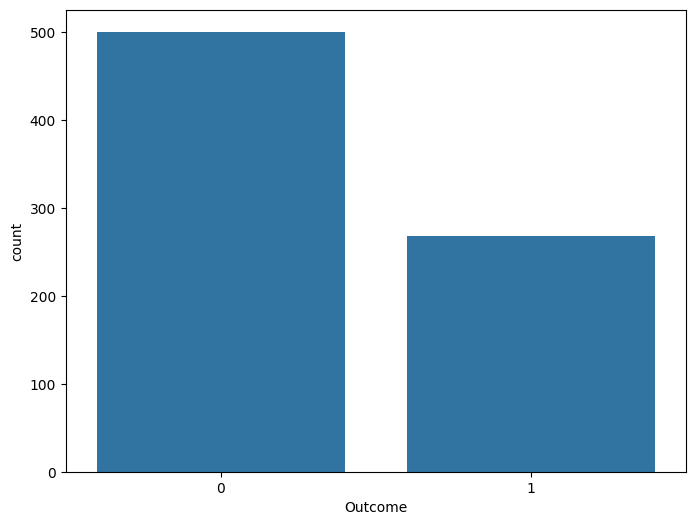

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.countplot(x='Outcome', data=diabetes)
plt.show()

In [7]:
diabetes['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [8]:
X_data=diabetes.drop(['Outcome'], axis=1)
X_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [10]:
y_data = diabetes['Outcome']
y_data.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_data,y_data,
test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(614, 8) (154, 8)
(614,) (154,)


In [12]:
import numpy as np

def impute_zero(data,col):
  df = data.loc[data[col]!=0, col]
  avg = np.sum(df)/len(df)
  k = len(data.loc[data[col]==0, col])
  k = len(data.loc[ data[col] == 0, col])
  data.loc[ data[col] == 0, col ] = avg
  print('%s : fixed %d, mean: %.3f' % (col, k, avg))
for col in cols:
  impute_zero(X_train, col)

Glucose : fixed 5, mean: 121.847
BloodPressure : fixed 24, mean: 72.239
SkinThickness : fixed 176, mean: 28.596
Insulin : fixed 290, mean: 154.330
BMI : fixed 7, mean: 32.352


/tmp/ipykernel_891/462872354.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '121.84729064039409' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[ data[col] == 0, col ] = avg
/tmp/ipykernel_891/462872354.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '72.23898305084745' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[ data[col] == 0, col ] = avg
/tmp/ipykernel_891/462872354.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '28.595890410958905' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[ data[col] == 0, col ] = avg
/tmp/ipykernel_891/462872354.py:8: FutureWarning: Setting an item of

In [13]:
(X_train[cols]==0).sum(axis=0)

,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


In [14]:
for col in cols:
  impute_zero(X_test,col)

Glucose : fixed 0, mean: 121.052
BloodPressure : fixed 11, mean: 73.091
SkinThickness : fixed 51, mean: 31.524
Insulin : fixed 84, mean: 161.186
BMI : fixed 4, mean: 32.883


/tmp/ipykernel_891/462872354.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '121.05194805194805' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[ data[col] == 0, col ] = avg
/tmp/ipykernel_891/462872354.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '73.0909090909091' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[ data[col] == 0, col ] = avg
/tmp/ipykernel_891/462872354.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '31.524271844660195' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[ data[col] == 0, col ] = avg
/tmp/ipykernel_891/462872354.py:8: FutureWarning: Setting an item of 

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s=scaler.fit_transform(X_train)
X_test_s=scaler.transform(X_test)

print(X_train_s[:5])

[[-5.26396861e-01 -1.25832567e+00  0.00000000e+00  4.22787785e-16
   0.00000000e+00  1.02533391e-15 -4.90734790e-01 -1.03594038e+00]
 [ 1.58804586e+00 -3.27397242e-01  8.07407436e-01 -5.46930179e-01
   0.00000000e+00 -5.99178052e-01  2.41502991e+00  1.48710085e+00]
 [-8.28460107e-01  5.70283740e-01 -2.17042447e+00 -1.14195109e+00
  -8.20791983e-01 -5.27026593e-01  5.49160552e-01 -9.48938958e-01]
 [-1.13052335e+00  1.30172750e+00 -1.83955426e+00  4.22787785e-16
   0.00000000e+00 -1.50828644e+00 -6.39291267e-01  2.79212217e+00]
 [ 6.81856121e-01  4.04046521e-01  6.41972330e-01  1.00012419e+00
   2.48169622e+00  1.99827450e+00 -6.86829340e-01  1.13909516e+00]]


In [16]:
y_train = y_train.values
y_test = y_test.values
print(type(y_train), type(y_test))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [17]:
from tensorflow import keras
from tensorflow.keras import layers

def build_model():
  model = keras.Sequential()
  model.add(layers.Dense(12, input_dim=8, activation='relu'))
  model.add(layers.Dense(8, activation='relu'))
  model.add(layers.Dense(1, activation='sigmoid'))
  return model

In [18]:
model=build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['acc'])

In [21]:
EPOCHS=500
BATCH_SIZE=32
history = model.fit(X_train_s, y_train,
                    epochs=EPOCHS,
                    batch_size = BATCH_SIZE,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 220ms/step - acc: 0.4236 - loss: 0.7830 - val_acc: 0.4065 - val_loss: 0.7458
Epoch 2/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - acc: 0.4868 - loss: 0.7316 - val_acc: 0.5122 - val_loss: 0.7012
Epoch 3/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.5886 - loss: 0.6851 - val_acc: 0.5854 - val_loss: 0.6650
Epoch 4/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.6599 - loss: 0.6478 - val_acc: 0.6585 - val_loss: 0.6350
Epoch 5/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.6823 - loss: 0.6162 - val_acc: 0.6667 - val_loss: 0.6088
Epoch 6/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.7108 - loss: 0.5889 - val_acc: 0.6911 - val_loss: 0.5848
Epoch 7/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.7312 - loss: 0.5635 - val_acc: 0.7236 - val_loss: 0.5630
Epoch 8/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.7373 - loss: 0.5419 - val_acc: 0.7317 - val_loss: 0.5460
Epoch 9/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.

In [23]:
import matplotlib.pyplot as plt
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch
  plt.figure(figsize=(16,8))
  plt.subplot(1,2,1)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
  plt.plot(hist['epoch'], hist['val_loss'], label = 'Val Loss')
  plt.legend()
  plt.subplot(1,2,2)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.plot(hist['epoch'], hist['acc'], label='Train Accuracy')
  plt.plot(hist['epoch'], hist['val_acc'], label = 'Val Accuracy')
  plt.legend()
  plt.show()

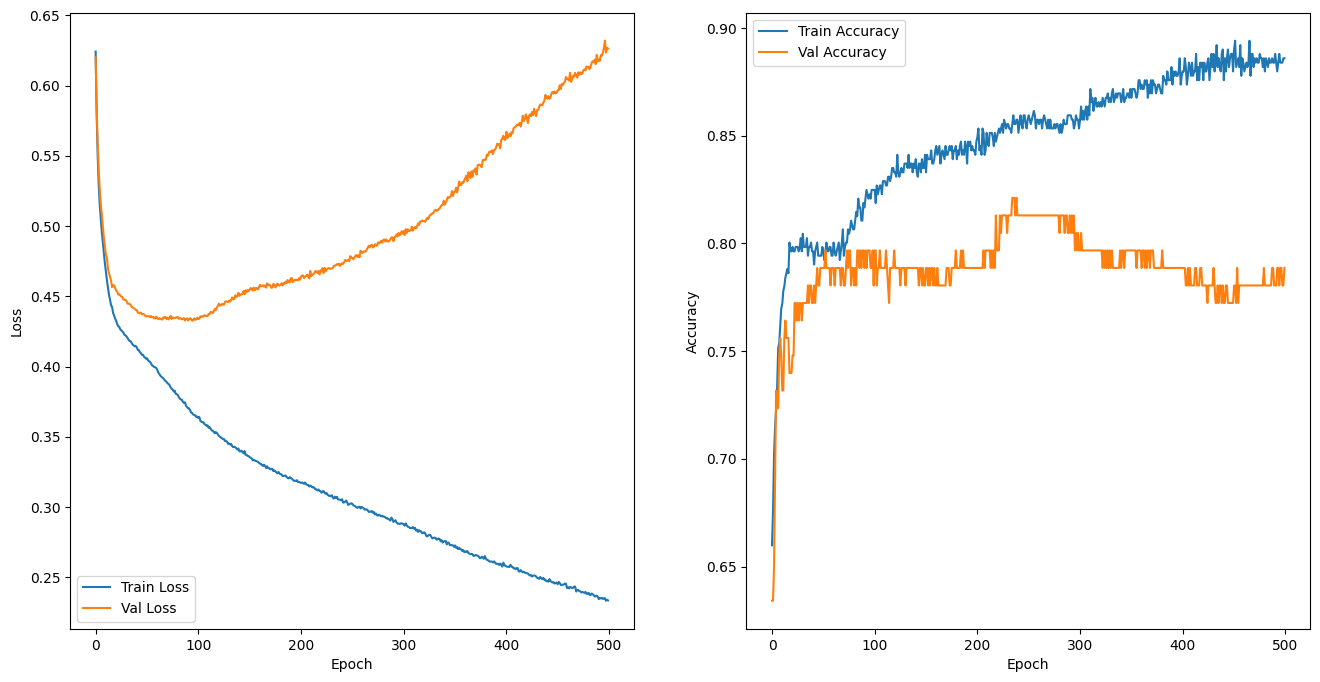

In [48]:
plot_history(history)

# 4. 이진분류

In [24]:
from tensorflow import keras

model = build_model()
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['acc'])

In [25]:
early_stop=keras.callbacks.EarlyStopping(monitor='var_loss', patience=10)

In [30]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, mode='min')

EPOCHS = 500
BATCH_SIZE=16
history = model.fit(X_train_s, y_train,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_split = 0.2,
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.7963 - loss: 0.4001 - val_acc: 0.7480 - val_loss: 0.4424
Epoch 2/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7943 - loss: 0.3995 - val_acc: 0.7480 - val_loss: 0.4433
Epoch 3/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7963 - loss: 0.3990 - val_acc: 0.7480 - val_loss: 0.4425
Epoch 4/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.8024 - loss: 0.3978 - val_acc: 0.7398 - val_loss: 0.4436
Epoch 5/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.8024 - loss: 0.3961 - val_acc: 0.7480 - val_loss: 0.4439
Epoch 6/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.8045 - loss: 0.3958 - val_acc: 0.7480 - val_loss: 0.4444
Epoch 7/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.8065 - loss: 0.3955 - val_acc: 0.7480 - val_loss: 0.4452
Epoch 8/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.8045 - loss: 0.3972 - val_acc: 0.7561 - val_loss: 0.4429
Epoch 9/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.8086

In [31]:
y_pred = model.predict(X_test_s)
y_pred

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


array([[0.4273476 ],
       [0.13705038],
       [0.07934821],
       [0.24305329],
       [0.4278884 ],
       [0.51801425],
       [0.00211742],
       [0.8229151 ],
       [0.6571557 ],
       [0.7366418 ],
       [0.2671702 ],
       [0.85060024],
       [0.4528958 ],
       [0.43264952],
       [0.03303606],
       [0.6827158 ],
       [0.10203492],
       [0.04100249],
       [0.83893263],
       [0.75912076],
       [0.11940555],
       [0.0518739 ],
       [0.48484895],
       [0.05446497],
       [0.6092611 ],
       [0.89930546],
       [0.12273909],
       [0.00471142],
       [0.08644481],
       [0.10179237],
       [0.9348556 ],
       [0.88896775],
       [0.89507306],
       [0.95434874],
       [0.8510752 ],
       [0.70397675],
       [0.9974152 ],
       [0.71262115],
       [0.2540571 ],
       [0.65997934],
       [0.02471114],
       [0.5901701 ],
       [0.57411087],
       [0.42666814],
       [0.01065251],
       [0.8069364 ],
       [0.84897476],
       [0.199

In [32]:
y_pred= (y_pred >0.5).astype(np.int32).flatten()
y_pred

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
      dtype=int32)

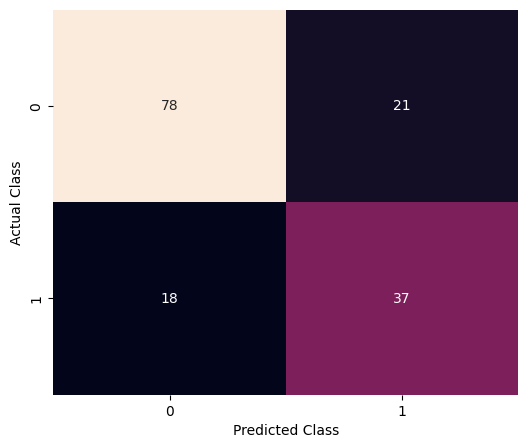

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cf_matrix, annot=True, cbar=False)
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score
def print_score(y_test, y_pred):
  print('precision: %.3f' % (precision_score(y_test, y_pred)))
  print('recall_score: %.3f' % (recall_score(y_test, y_pred)))
  print('f1_score: %.3f' % (f1_score(y_test, y_pred)))

In [35]:
print_score(y_test, y_pred)

precision: 0.638
recall_score: 0.673
f1_score: 0.655


In [36]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

